In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt

class HTGR_Prismatik:
    def __init__(self, constant, powerdensity):
        self.inputconstant(constant)
        self.pd_matrix = np.array(powerdensity) 
        
        self.rf_area = self.calculate_rf_area()
        self.area_coolant = self.calculate_areapin_coolant()
        self.dz_val = self.calculate_dz()
        self.flow_channel = self.calculate_flow_per_channel()

    def inputconstant(self, c):
        self.rfi = c.get("innerfuel_compactradius")
        self.rfo = c.get("outerfuel_compactradius")
        self.rsi = c.get("innersleeve_radius")
        self.rso = c.get("outersleeve_radius")
        self.rci = c.get("coolanthole_radius")
        
        self.height_reactor = c.get("height_reactor")
        self.node_axial = c.get("node_axial")
        self.grid_axial = c.get("grid_axial")
        self.n_channel = c.get("number_coolantchannel")
        self.n_block = c.get("number_fuelblock")
        self.total_pwr = c.get("total_termalpwr")
        self.tin_inlet = c.get("coolant_inlettemp") + 273.15
        self.tout_target = c.get("coolant_outlettemp") + 273.15
        
        self.cp_he = c.get("helium_cp")
        self.k_graphite = c.get("k_graphite")
        self.h_coolant = c.get("q_helium", 258.86) 
        self.h_gap = c.get("Gap_HT")       
        self.k_fuel = c.get("cc_sic")

    def calculate_rf_area(self):
        return math.pi * (self.rfo**2 - self.rfi**2)

    def calculate_areapin_coolant(self):
        return math.pi * (self.rci**2 - self.rso**2)

    def calculate_dz(self):
        return self.height_reactor / (self.node_axial - 1)

    def calculate_flow_per_channel(self):
        dt = self.tout_target - self.tin_inlet
        total_m_dot = (self.total_pwr * 1e6) / (self.cp_he * dt)
        return total_m_dot / (self.n_channel * self.n_block)

    def solve_thermal_distribution(self):
        results = {"T_he": [], "T_so": [], "T_si": [], "T_fo": [], "T_fi": []}

        for g in range(self.grid_axial):
            pd_grid = self.pd_matrix[g]
            h_list, so_list, si_list, fo_list, fi_list = [], [], [], [], []
            t_current_he = self.tin_inlet

            for z in range(self.node_axial):
                q_vol = pd_grid[z] * 1e6 
                q_prime = q_vol * self.rf_area 

                if q_vol <= 0:
                    h_list.append(round(t_current_he, 2))
                    so_list.append(round(t_current_he, 2))
                    si_list.append(round(t_current_he, 2))
                    fo_list.append(round(t_current_he, 2))
                    fi_list.append(round(t_current_he, 2))
                else:
                    t_he = t_current_he + (q_prime * self.dz_val) / (self.flow_channel * self.cp_he)
                    t_so = t_he + q_prime / (2 * math.pi * self.h_coolant * self.rso)
                    t_si = t_so + (q_prime / (2 * math.pi * self.k_graphite)) * math.log(self.rso / self.rsi)
                    t_fo = t_si + q_prime / (2 * math.pi * self.rfo * self.h_gap)
                    term_bracket = 0.5 + (self.rfi**2 / (self.rfo**2 - self.rfi**2)) * math.log(self.rfi / self.rfo)
                    t_fi = t_fo + (q_prime / (2 * math.pi * self.k_fuel)) * term_bracket

                    t_current_he = t_he
                    h_list.append(round(t_he, 2)); so_list.append(round(t_so, 2))
                    si_list.append(round(t_si, 2)); fo_list.append(round(t_fo, 2))
                    fi_list.append(round(t_fi, 2))

            results["T_he"].append(h_list)
            results["T_so"].append(so_list)
            results["T_si"].append(si_list)
            results["T_fo"].append(fo_list)
            results["T_fi"].append(fi_list)
            
        return results
    
const = {
    "innerfuel_compactradius": 0.005,
    "outerfuel_compactradius": 0.013,
    "innersleeve_radius": 0.013125,
    "outersleeve_radius": 0.017,
    "coolanthole_radius": 0.025,
    "number_coolantchannel": 33,
    "number_fuelblock": 30,
    "total_termalpwr": 30,
    "coolant_inlettemp": 395,
    "coolant_outlettemp": 950,
    "height_reactor": 5.8,
    "node_axial": 21,
    "grid_axial": 24,
    "number_axiallayer": 20,
    "helium_cp": 5192,
    "k_graphite": 32.882,
    "q_helium": 258.86,
    "Gap_HT": 1457.6,
    "cc_sic": 13.9
}

dummy_pd = np.random.uniform(5, 15, (24, 21))
model = HTGR_Prismatik(const, dummy_pd)
hasil = model.solve_thermal_distribution()

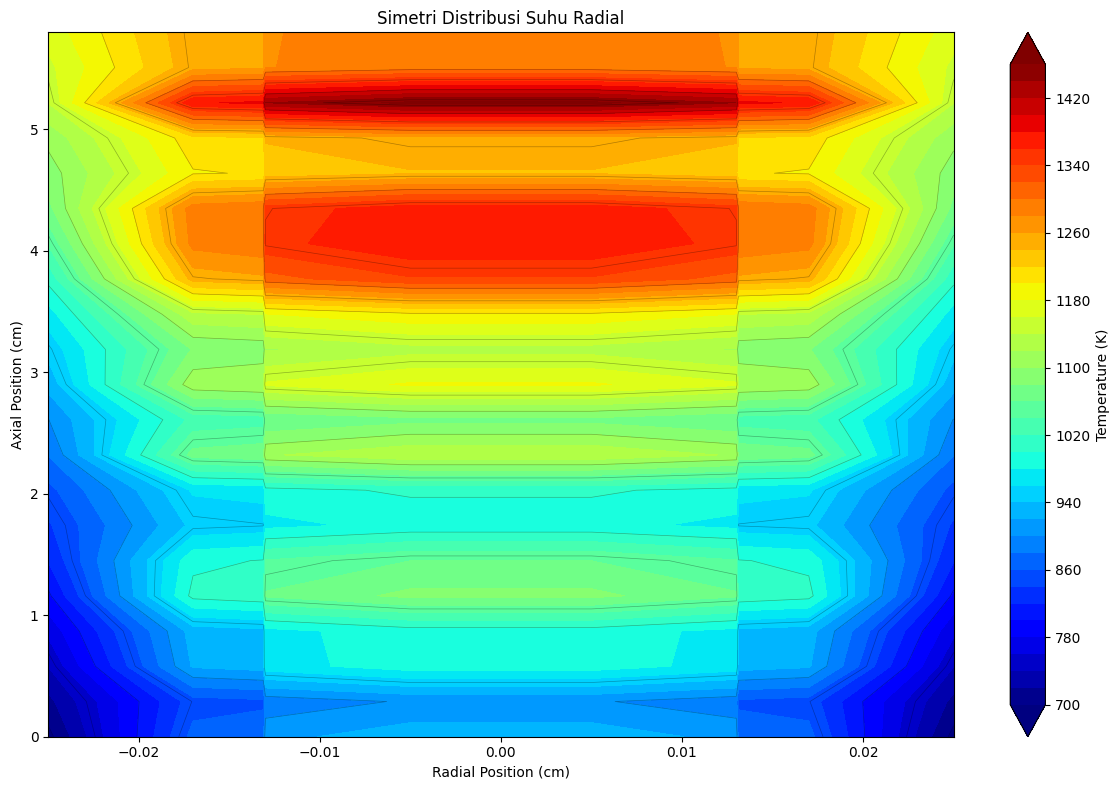

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_contour_symmetric(results, model):
    r_positive = np.array([0, model.rfi, model.rfo, model.rsi, model.rso, model.rci])
    r_coords = np.concatenate([-r_positive[::-1], r_positive[1:]])
    z_coords = np.linspace(0, model.height_reactor, model.node_axial)
    grid_idx = 0
    t_fi = np.array(results["T_fi"][grid_idx])
    t_fo = np.array(results["T_fo"][grid_idx])
    t_si = np.array(results["T_si"][grid_idx])
    t_so = np.array(results["T_so"][grid_idx])
    t_he = np.array(results["T_he"][grid_idx])
    side_data = np.column_stack([t_fi, t_fi, t_fo, t_si, t_so, t_he])
    temp_data = np.column_stack([side_data[:, ::-1], side_data[:, 1:]])
    plt.figure(figsize=(12, 8))
    R, Z = np.meshgrid(r_coords, z_coords)
    contour = plt.contourf(R, Z, temp_data, levels=50, cmap='jet', extend='both')

    plt.contour(R, Z, temp_data, levels=15, colors='black', linewidths=0.5, alpha=0.3)
    plt.colorbar(contour, label='Temperature (K)')
    plt.xlabel('Radial Position (cm)')
    plt.ylabel('Axial Position (cm)')
    plt.title('Simetri Distribusi Suhu Radial')
    #plt.axvline(x=0, color='white', linestyle='--', alpha=0.5, label='Centerline')
    plt.xlim(-0.025, 0.025)
    plt.grid(False)
    plt.tight_layout()
    plt.show()
plot_2d_contour_symmetric(hasil, model)